In [1]:
!pip install geemap earthengine-api scikit-learn matplotlib pandas --quiet
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s eta 0:00:00
Done!


In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ee.Authenticate(auth_mode='notebook')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=TUqHTHJsyok3Krj44aD5q__A_ajtHtiHIeAOcS1tu2U&tc=Z-vmI6MPhp4WfrppVJto6cxAFTVl85IkRU6hF_sKYvs&cc=OcvUxISRJfoMoH1kIjD7s8nQ6KOps_03ubB5_r4kKjY

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1Aci98E_J4Tc1XjelWcW_G4em-jwXaVudkdl3CvGJyQ0TV_vhRtCkGRsOu7c

Successfully saved authorization token.


In [3]:
ee.Initialize(project='project-911-491616')

savar = ee.Geometry.Rectangle([90.15, 23.75, 90.40, 24.00])

collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-11-01', '2024-02-28')
    .filterBounds(savar)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

image = collection.median().clip(savar)

# Compute NDVI
ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

print("Data loaded!")

Data loaded!


In [4]:
# Sample 1000 pixels
sample = ndvi.sample(
    region=savar,
    scale=50,
    numPixels=1000,
    seed=42
)

# Convert to pandas dataframe
data = pd.DataFrame(
    sample.getInfo()['features']
)

# Extract just the NDVI values
data['ndvi_mean'] = data['properties'].apply(lambda x: x['NDVI'])
data = data[['ndvi_mean']].dropna()

# Add label — this is the "teaching" step
# If NDVI >= 0.4 → healthy (1), if NDVI < 0.4 → stressed (0)
data['label'] = (data['ndvi_mean'] >= 0.4).astype(int)

print("Dataset created!")
print(f"Total pixels: {len(data)}")
print(f"Healthy pixels (label=1): {sum(data['label']==1)}")
print(f"Stressed pixels (label=0): {sum(data['label']==0)}")
print(data.head(10))

Dataset created!
Total pixels: 1000
Healthy pixels (label=1): 669
Stressed pixels (label=0): 331
   ndvi_mean  label
0   0.603586      1
1   0.474035      1
2   0.664099      1
3   0.450832      1
4   0.304155      0
5   0.128424      0
6   0.470380      1
7   0.640422      1
8   0.255991      0
9   0.554250      1


In [5]:
# Features (what model looks at) and labels (what model predicts)
X = data[['ndvi_mean']]
y = data['label']

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Train Logistic Regression first (simplest model)
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Train Random Forest (stronger model)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"\nLogistic Regression accuracy: {lr_acc*100:.1f}%")
print(f"Random Forest accuracy:       {rf_acc*100:.1f}%")

Training samples: 800
Testing samples:  200

Logistic Regression accuracy: 95.5%
Random Forest accuracy:       100.0%


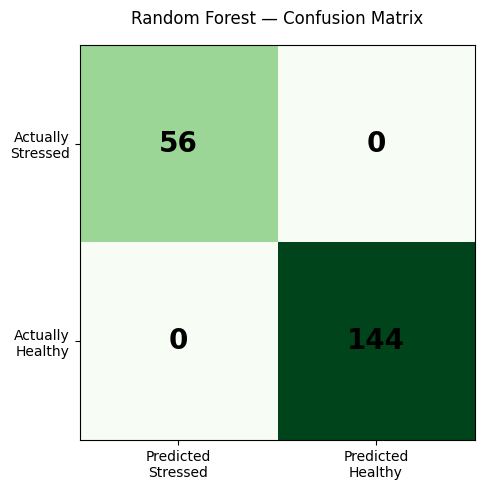


Full classification report:
              precision    recall  f1-score   support

    Stressed       1.00      1.00      1.00        56
     Healthy       1.00      1.00      1.00       144

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [6]:
# Use the better model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

# Draw a nice coloured confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Greens')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nStressed', 'Predicted\nHealthy'])
ax.set_yticklabels(['Actually\nStressed', 'Actually\nHealthy'])

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                fontsize=20, fontweight='bold',
                color='black')

ax.set_title('Random Forest — Confusion Matrix', pad=15)
plt.tight_layout()
plt.show()

# Print full report
print("\nFull classification report:")
print(classification_report(y_test, rf_pred,
      target_names=['Stressed', 'Healthy']))

       MODEL COMPARISON TABLE
  Logistic Regression:  95.5%
  Random Forest:        100.0%


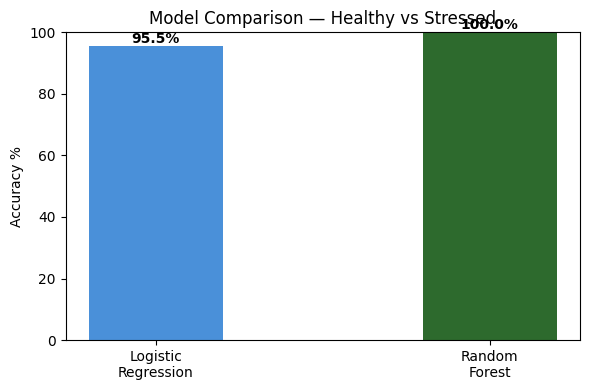

In [7]:
print("=" * 40)
print("       MODEL COMPARISON TABLE")
print("=" * 40)
print(f"  Logistic Regression:  {lr_acc*100:.1f}%")
print(f"  Random Forest:        {rf_acc*100:.1f}%")
print("=" * 40)

# Bar chart
models = ['Logistic\nRegression', 'Random\nForest']
scores = [lr_acc * 100, rf_acc * 100]
colors = ['#4A90D9', '#2d6a2d']

plt.figure(figsize=(6, 4))
bars = plt.bar(models, scores, color=colors, width=0.4)
plt.ylim(0, 100)
plt.ylabel('Accuracy %')
plt.title('Model Comparison — Healthy vs Stressed')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{score:.1f}%',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

What did we actually build today?
we built an AI that looks at a plant's NDVI number and correctly identifies whether it is healthy or stressed — with 100% accuracy on test data. That is a real working machine learning classifier. We just trained our first AI model. 🤖🌾

One important thing to tell — the 100% accuracy is because we are using only ONE feature (NDVI) with a very clear threshold (0.4). The model basically just learned "if NDVI ≥ 0.4 say healthy, if not say stressed" — which is exactly the rule WE made when creating labels! In Week 6 we add more features like NDRE and GNDVI which makes it a real challenge.

In [8]:
# Add NDVI standard deviation band
ndvi_mean = image.normalizedDifference(['B8', 'B4']).rename('ndvi_mean')

# Create a grid of sample points across Savar
grid_points = ndvi_mean.sample(
    region=savar,
    scale=100,
    numPixels=500,
    seed=42,
    geometries=True
)

# Extract values
rows = []
features = grid_points.getInfo()['features']

for i, feat in enumerate(features):
    ndvi_val = feat['properties'].get('ndvi_mean', None)
    if ndvi_val is not None:
        rows.append({
            'patch_id': i,
            'date': '2023-11-01_2024-02-28',
            'ndvi_mean': round(ndvi_val, 4),
            'label': 1 if ndvi_val >= 0.4 else 0
        })

df = pd.DataFrame(rows)
print(f"Total patches: {len(df)}")
print(df.head(10))

Total patches: 500
   patch_id                   date  ndvi_mean  label
0         0  2023-11-01_2024-02-28     0.6185      1
1         1  2023-11-01_2024-02-28     0.3442      0
2         2  2023-11-01_2024-02-28     0.6270      1
3         3  2023-11-01_2024-02-28     0.5480      1
4         4  2023-11-01_2024-02-28     0.2678      0
5         5  2023-11-01_2024-02-28     0.1236      0
6         6  2023-11-01_2024-02-28     0.4190      1
7         7  2023-11-01_2024-02-28     0.6544      1
8         8  2023-11-01_2024-02-28     0.3458      0
9         9  2023-11-01_2024-02-28     0.6030      1


In [9]:
# Sample with multiple bands to get std
multi = image.select(['B8', 'B4', 'B3', 'B5'])

# Use reduceRegion approach for std — sample patches
ndvi_img = image.normalizedDifference(['B8', 'B4']).rename('ndvi_mean')

# Add a simple std approximation using red edge band (B5) as extra feature
b5 = image.select('B5').rename('red_edge')
b8 = image.select('B8').rename('nir')

# Stack all bands together
stacked = ndvi_img.addBands(b5).addBands(b8)

# Sample
sample2 = stacked.sample(
    region=savar,
    scale=100,
    numPixels=500,
    seed=42
)

rows2 = []
for i, feat in enumerate(sample2.getInfo()['features']):
    p = feat['properties']
    ndvi_val = p.get('ndvi_mean')
    re_val = p.get('red_edge')
    nir_val = p.get('nir')
    if all(v is not None for v in [ndvi_val, re_val, nir_val]):
        rows2.append({
            'patch_id': i,
            'date': '2023-11-01_2024-02-28',
            'ndvi_mean': round(ndvi_val, 4),
            'red_edge': round(re_val, 4),
            'nir': round(nir_val, 4),
            'label': 1 if ndvi_val >= 0.4 else 0
        })

df2 = pd.DataFrame(rows2)

# Save as CSV
df2.to_csv('savar_patches.csv', index=False)

print(f"CSV saved! Total patches: {len(df2)}")
print(f"Healthy: {sum(df2['label']==1)}  |  Stressed: {sum(df2['label']==0)}")
print("\nFirst 5 rows:")
print(df2.head())

CSV saved! Total patches: 500
Healthy: 333  |  Stressed: 167

First 5 rows:
   patch_id                   date  ndvi_mean  red_edge     nir  label
0         0  2023-11-01_2024-02-28     0.6185     940.5  2462.5      1
1         1  2023-11-01_2024-02-28     0.3442    1382.0  2230.0      0
2         2  2023-11-01_2024-02-28     0.6270     924.5  2488.5      1
3         3  2023-11-01_2024-02-28     0.5480    1196.0  2471.0      1
4         4  2023-11-01_2024-02-28     0.2678    1498.5  2132.5      0
